In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [53]:
data = pd.read_csv("train.csv")
data['SexF'] = (data['Sex'] == 'female').astype(int)
essential_features = ['Pclass', 'SexF', 'Age', 'Siblings/Spouses Aboard', 'Parents/Children Aboard', 'Fare', 'Survived']
data = data[essential_features]

In [54]:
mean = data.mean()
std = data.std()
data = (data-mean)/std

In [55]:
def sigmoid(z):
    return (1/(1+np.exp(-z)))

In [56]:
def LogisticRegressionModel(w,b,data,LR):
    m = len(data)
    w_gradient = np.zeros(len(w))
    b_gradient = 0
    loss = 0
    for i in range (m):
        x = data.iloc[i].values[:-1]
        y = data.iloc[i].values[-1]
        z = np.dot(w,x) + b
        error = sigmoid(z) - y
        w_gradient += error*x
        b_gradient =+ error
        loss += - (y*np.log(sigmoid(z)) + (1-y)*np.log(1-sigmoid(z)))
    w = w-(1/m)*w_gradient*LR
    b = b - (1/m)*b_gradient*LR
    return (w,b,loss)
print(data)

       Pclass      SexF       Age  Siblings/Spouses Aboard  \
0    0.826213 -0.775715 -0.516323                 0.406014   
1   -1.569390  1.286900  0.609757                 0.406014   
2    0.826213  1.286900 -0.234803                -0.491573   
3   -1.569390  1.286900  0.398617                 0.406014   
4    0.826213 -0.775715  0.398617                -0.491573   
..        ...       ...       ...                      ...   
572  0.826213 -0.775715 -0.727463                -0.491573   
573 -0.371588  1.286900  0.328237                -0.491573   
574 -1.569390  1.286900  0.680137                 0.406014   
575  0.826213  1.286900 -0.797843                 0.406014   
576  0.826213 -0.775715  0.187477                -0.491573   

     Parents/Children Aboard      Fare  Survived  
0                  -0.482881 -0.527431 -0.810497  
1                  -0.482881  0.840329  1.231672  
2                  -0.482881 -0.513013  1.231672  
3                  -0.482881  0.451931  1.231672  


In [57]:
b = 0
w = np.zeros(len(data.columns) - 1)
LR = 0.001
epochs = 1500
loss_history = []
for i in range (epochs):
    if i%100==0:
        print ("Epochs:",i)
        print ("Loss", loss_history[-1] if loss_history else None)
    w,b,loss = LogisticRegressionModel(w,b,data,LR)
    loss_history.append(loss)
print (w,b)

Epochs: 0
Loss None
Epochs: 100
Loss 375.9410873022255
Epochs: 200
Loss 353.2215534221962
Epochs: 300
Loss 331.9160677458065
Epochs: 400
Loss 311.90761409534144
Epochs: 500
Loss 293.08620946032573
Epochs: 600
Loss 275.350088028085
Epochs: 700
Loss 258.6061006229305
Epochs: 800
Loss 242.7695928608213
Epochs: 900
Loss 227.7639732266204
Epochs: 1000
Loss 213.52012060750664
Epochs: 1100
Loss 199.97572845991147
Epochs: 1200
Loss 187.07464451250075
Epochs: 1300
Loss 174.76623921522355
Epochs: 1400
Loss 163.00481983246473
[-0.32239568  0.68506255 -0.09962702 -0.08757916  0.07488127  0.20189627] 0.002211063011868783


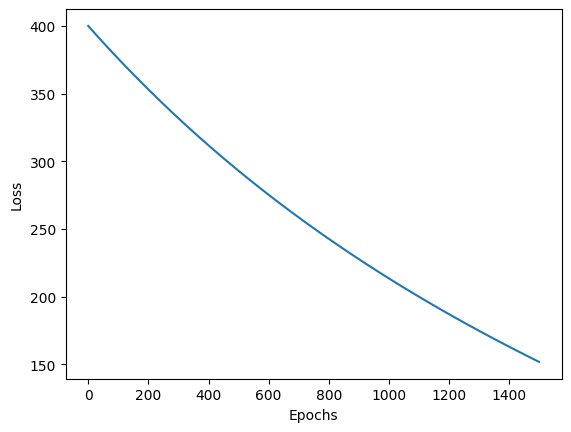

In [58]:
plt.plot(range(len(loss_history)), loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [59]:
test_data = pd.read_csv("test.csv")
test_data['SexF'] = (test_data['Sex'] == 'female').astype(int)
test_data = test_data[essential_features[:-1]]

In [60]:
test_data = (test_data - mean[:-1]) / std[:-1]
def predict(w, b, data):
    z = np.dot(data, w) + b
    predictions = sigmoid(z)
    return predictions
test_predictions = predict(w, b, test_data.values)
print("Raw Predictions for Survival:")
print(test_predictions)

Raw Predictions for Survival:
[0.74078892 0.84381428 0.35409819 0.49305515 0.31102198 0.86694283
 0.35447436 0.4974962  0.30147722 0.30147722 0.28182739 0.79558543
 0.2652189  0.65419544 0.3634356  0.2991245  0.73172742 0.25648735
 0.30665929 0.4687719  0.72422908 0.27265904 0.49375484 0.27001789
 0.48018236 0.27195945 0.28966074 0.4984541  0.77156858 0.86365247
 0.72228477 0.30204594 0.63513541 0.30120484 0.28263548 0.78653579
 0.29328262 0.6226486  0.76088227 0.38424031 0.28367115 0.4763027
 0.31528116 0.30277758 0.31033669 0.44109215 0.33604382 0.83937327
 0.29546548 0.30712556 0.40613593 0.25962693 0.48969087 0.46039535
 0.66950881 0.71873371 0.28680959 0.3962322  0.74205727 0.27104175
 0.30425983 0.83134614 0.68027733 0.33148713 0.67018193 0.49183191
 0.30578423 0.45314745 0.30250071 0.63728012 0.29986305 0.75906815
 0.30330505 0.6488219  0.64455444 0.41505779 0.29400797 0.63466742
 0.3917953  0.580716   0.53000496 0.274872   0.45819684 0.28073315
 0.2879423  0.40150714 0.38845873

In [61]:
binary_predictions = (test_predictions > 0.5).astype(int)
print("Binary Predictions for Survival:")
print(binary_predictions)

Binary Predictions for Survival:
[1 1 0 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 1 0 0 1 0
 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 1 0 1
 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 1 1
 1 0 0 0 0 0 1 1 0 1 0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0
 1 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1
 0 1 0 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1
 0 0 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 0 0 1 1 0 1 1 1 0 0 0 1 0 0 1 1 0
 0 0 1 1 0 1 0 0 1 0 1 1 0 0]


In [62]:
test_data = pd.read_csv("test.csv")
matches = np.sum(binary_predictions == test_data['Survived'].values)
misses = len(test_data) - matches

In [63]:
result_df = pd.DataFrame({
    'Predicted Survival': binary_predictions,
    'Actual Survival': test_data['Survived'].values,
    'Hit/Miss': np.where(binary_predictions == test_data['Survived'].values, 'Hit', 'Miss')
})
print(result_df)

print("Number of Matches:", matches)
print("Number of Misses:", misses)
total_samples = len(test_data)
accuracy = matches / total_samples
print("Accuracy:", accuracy*100, "%")


     Predicted Survival  Actual Survival Hit/Miss
0                     1                1      Hit
1                     1                1      Hit
2                     0                0      Hit
3                     0                0      Hit
4                     0                0      Hit
..                  ...              ...      ...
305                   0                0      Hit
306                   1                1      Hit
307                   1                0     Miss
308                   0                1     Miss
309                   0                0      Hit

[310 rows x 3 columns]
Number of Matches: 244
Number of Misses: 66
Accuracy: 78.70967741935485 %
